<a href="https://colab.research.google.com/github/FriendlyIndr/Spam_Detection/blob/main/Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Pandas library for DataFrame
import pandas as pd

# NLTK Library for Natural Language Processing
import nltk
# PorterStemmer for Stemming the Words
from nltk.stem.porter import PorterStemmer

In [26]:
import io
import requests

# Import spam.csv
file_id = "19Yz5vBQ3T174xeSOOqVzw3rWWm39stsf"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

response = requests.get(url)

print(response.status_code)
print(response.headers.get("content-type"))
print(response.text[:500])

df = pd.read_csv(
    io.BytesIO(response.content),
    encoding="latin1"
    )

# Checking the first five values in the data
df.head()

200
application/octet-stream
v1,v2,,,
ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,
ham,Ok lar... Joking wif u oni...,,,
spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,,,
ham,U dun say so early hor... U c already then say...,,,
ham,"Nah I don't think he goes to usf, he lives around here though",,,
spam,"FreeMsg Hey there darling it'


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [12]:
# Checking for null values
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [14]:
# Checking the last five values in the data
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [16]:
# Taking the required columns in the dataset
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
# Dimensions of the dataset
df.shape

(5572, 2)

In [20]:
# Checking for the classes in the data
df.groupby('label').size()

,0
label,
ham,4825
spam,747


<Axes: xlabel='label'>

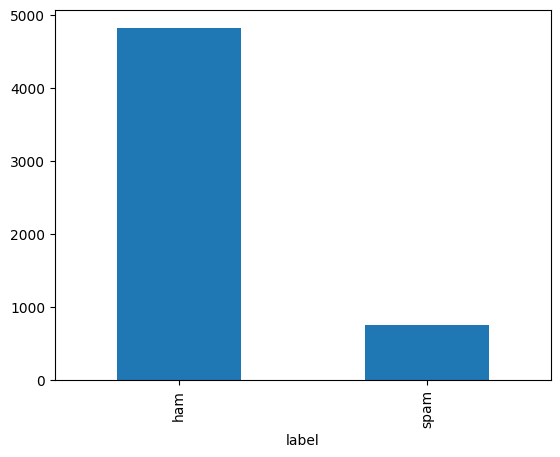

In [23]:
# Plotting
# Plot the label in the dataset
df['label'].value_counts().plot(kind='bar')